# Final Case Study: Cost-Based Classification on an Anonymized Dataset
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater

## Introduction

The client provides 160,000 anonymized samples with 50 features and a binary target, and cares about exactly one thing: minimizing the dollar cost of prediction errors, where a false positive costs `$47`, a false negative costs `$7`, and correct predictions are free. We clean five messy string columns, impute a small number of missing values, and compare a baseline logistic regression model against a dense neural network in PyTorch. The linear model barely improves on the $449,379 all-zeros benchmark, while the network with a cost-tuned 0.87 decision threshold brings the unbiased out-of-fold cost over all 160,000 rows down to `$73,539`, a six-fold reduction.

## Imports

In [1]:
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("lightning.fabric").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

torch.cuda.is_available()

True

## Data Loading

The data is a single CSV with 50 anonymized features (x0 through x49) and the target y in the last column.

In [2]:
df = pd.read_csv("final_project(5).csv")
print(df.shape)
df.head()

(160000, 51)


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
0,-0.166563,-3.961588,4.621113,2.481908,-1.800135,0.804684,6.718751,-14.789997,-1.040673,-4.204950,...,-1.497117,5.414063,-2.325655,1.674827,-0.264332,60.781427,-7.689696,0.151589,-8.040166,0
1,-0.149894,-0.585676,27.839856,4.152333,6.426802,-2.426943,40.477058,-6.725709,0.896421,0.330165,...,36.292790,4.490915,0.762561,6.526662,1.007927,15.805696,-4.896678,-0.320283,16.719974,0
2,-0.321707,-1.429819,12.251561,6.586874,-5.304647,-11.311090,17.812850,11.060572,5.325880,-2.632984,...,-0.368491,9.088864,-0.689886,-2.731118,0.754200,30.856417,-7.428573,-2.090804,-7.869421,0
3,-0.245594,5.076677,-24.149632,3.637307,6.505811,2.290224,-35.111751,-18.913592,-0.337041,-5.568076,...,15.691546,-7.467775,2.940789,-6.424112,0.419776,-72.424569,5.361375,1.806070,-7.670847,0
4,-0.273366,0.306326,-11.352593,1.676758,2.928441,-0.616824,-16.505817,27.532281,1.199715,-4.309105,...,-13.911297,-5.229937,1.783928,3.957801,-0.096988,-14.085435,-0.208351,-0.894942,15.724742,1


## EDA

The classes are moderately imbalanced at roughly 60/40, which matters less than usual here since the costs, not accuracy, drive every decision.

In [3]:
df["y"].value_counts()

y
0    95803
1    64197
Name: count, dtype: int64

Five columns are strings: x24 is a region, x29 a month, and x30 a weekday (these include some typos). x32 and x37 are numerics contaminated with % and $ symbols.

In [4]:
for col in df.select_dtypes(exclude="number").columns:
    print(col, df[col].unique())

x24 <StringArray>
['euorpe', 'asia', 'america', nan]
Length: 4, dtype: str
x29 <StringArray>
[   'July',     'Aug',     'Jun',     'May',   'sept.',     'Apr',     'Nov',
     'Oct',       nan,     'Mar',     'Feb',     'Dev', 'January']
Length: 13, dtype: str
x30 <StringArray>
['tuesday', 'wednesday', 'thurday', 'monday', 'friday', nan]
Length: 6, dtype: str
x32 <StringArray>
[  '0.0%', '-0.02%', '-0.01%',  '0.01%', '-0.03%',  '0.02%',  '-0.0%',
 '-0.04%',      nan,  '0.03%',  '0.04%', '-0.05%',  '0.05%']
Length: 13, dtype: str
x37 <StringArray>
[ '$1313.96',  '$1962.78',   '$430.47', '$-2366.29',  '$-620.66',  '$-196.45',
  '$-241.04',   '$621.35',  '$-301.89',  '$-484.09',
 ...
 '$-1788.89',   '$134.18',  '$-677.95', '$-1012.45', '$-1720.76', '$-1177.33',
  '$-823.35',  '$1588.65',   '$439.21', '$-1229.34']
Length: 129199, dtype: str


Every column has a small scatter of missing values. Since we must produce a prediction for every row, and since there are relatively few of these missing values, we impute rather than drop.

In [5]:
nulls = df.isnull().sum()
print(nulls.describe())
print("rows with any null:", df.isnull().any(axis=1).sum())

count    51.000000
mean     31.529412
std       7.465529
min       0.000000
25%      27.000000
50%      31.000000
75%      37.000000
max      47.000000
dtype: float64
rows with any null: 1608


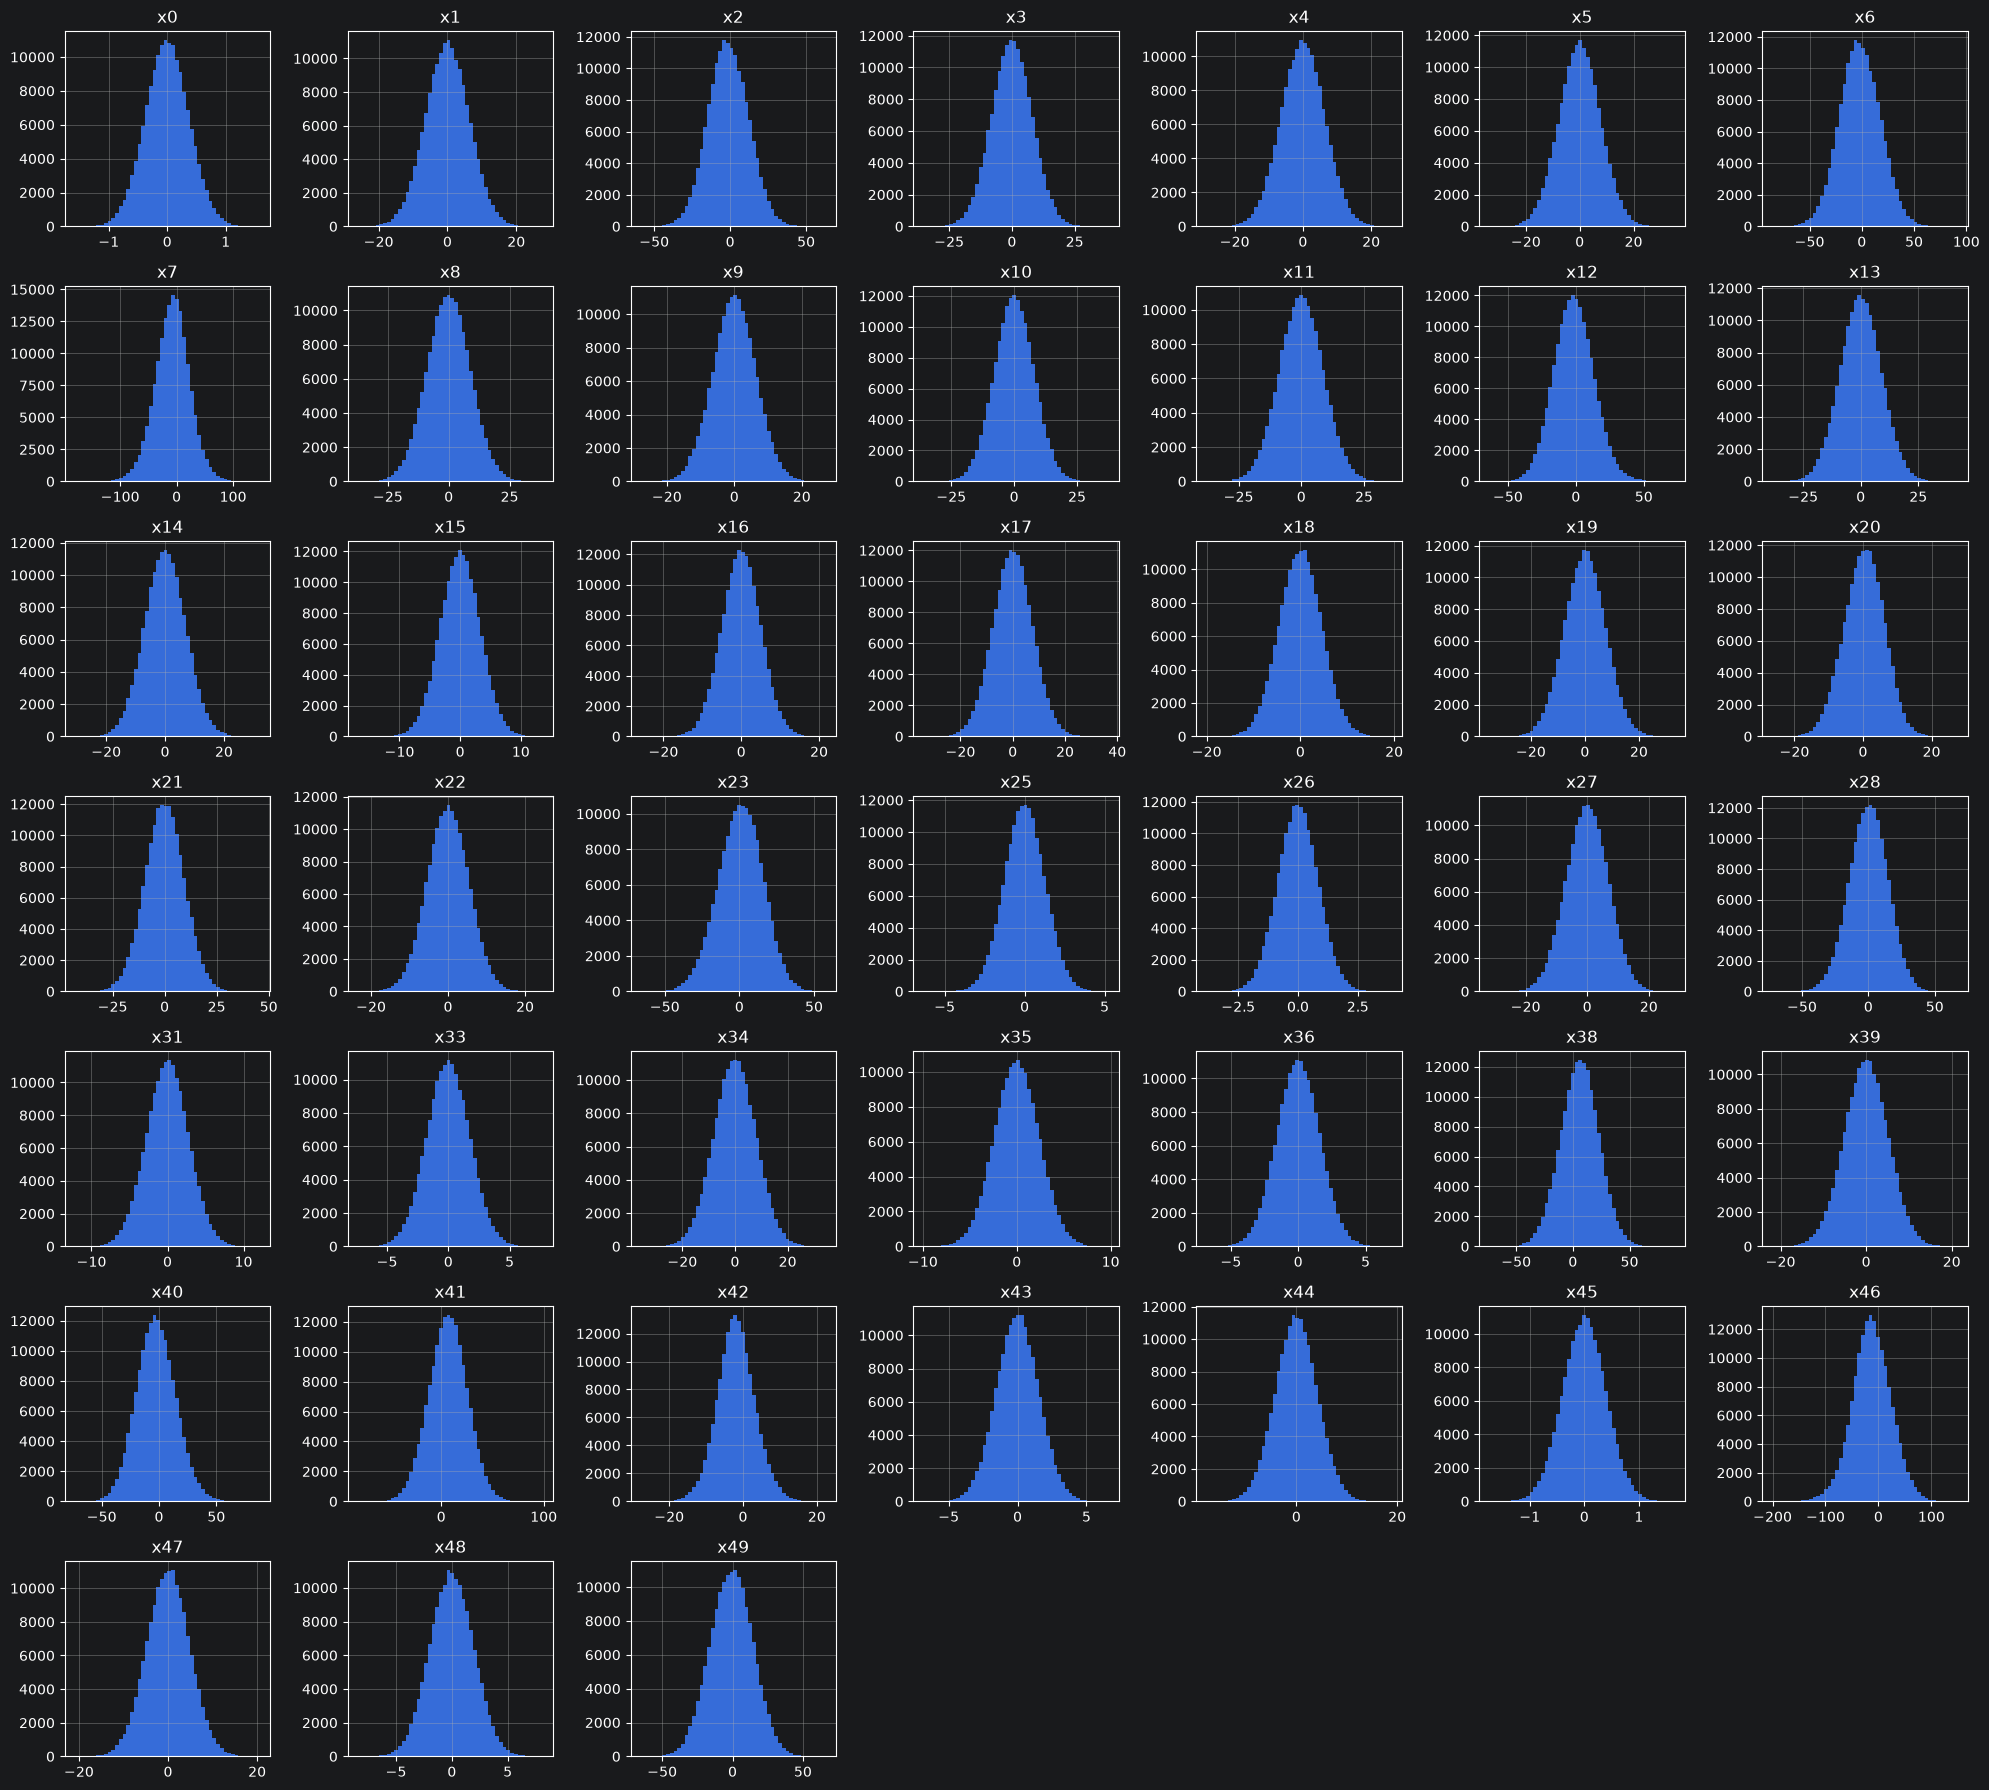

In [6]:
df.select_dtypes("number").drop(columns="y").hist(figsize=(20, 18), bins=50)
plt.tight_layout()
plt.show()

Before any modeling we want to see the benchmark range of outcomes based on the client's cost rules. Predicting all zeros costs `$7` per positive and is the number any model must beat; predicting all ones is ten times as expensive.

In [7]:
FP_COST, FN_COST = 47, 7
print("all zeros: $", FN_COST * (df["y"] == 1).sum())
print("all ones:  $", FP_COST * (df["y"] == 0).sum())

all zeros: $ 449379
all ones:  $ 4502741


## Data Preparation

We strip the % and $ symbols to recover x32 and x37 as numerics, one-hot encode the three true categoricals with missing values as their own category, and impute the missing numeric values to the median. We chose median because it's resistant to outliers, which could come into play on x37 (which has a wide range of dollar values).

In [8]:
df["x32"] = df["x32"].str.replace("%", "").astype(float)
df["x37"] = df["x37"].str.replace("$", "", regex=False).astype(float)
df = pd.get_dummies(df, columns=["x24", "x29", "x30"], dummy_na=True)
df = df.fillna(df.median(numeric_only=True))

X = df.drop(columns="y").astype(np.float32)
y = df["y"].values
print(X.shape, "nulls remaining:", X.isnull().sum().sum())

(160000, 70) nulls remaining: 0


## Logistic Regression Baseline

A linear baseline sets the floor. We scale all 70 columns and generate out-of-fold probabilities with cross_val_predict over a stratified 5-fold split, so every prediction comes from a model that never saw that row.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_probs = cross_val_predict(LogisticRegression(max_iter=1000), X_scaled, y, cv=skf,
                             method="predict_proba", n_jobs=-1)[:, 1]

### Threshold Sweep

With a `$47` false positive against a `$7` false negative, the theoretical optimum predicts 1 only when p >= 47/54 (~0.87). We sweep thresholds on the out-of-fold probabilities to find the optimal threshold based on observed costs.

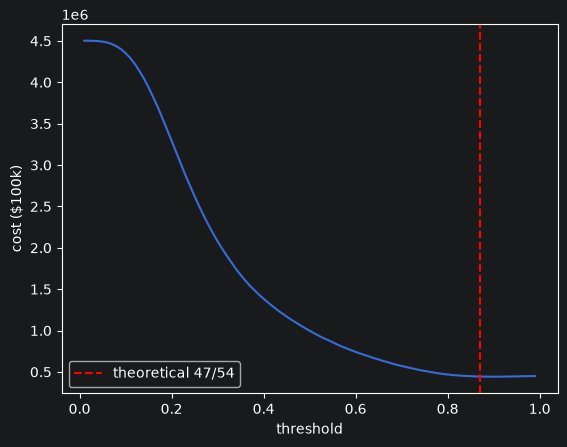

best threshold: 0.9 cost: $ 441990


In [20]:
thresholds = np.arange(0.01, 1.0, 0.01)
lr_costs = [FP_COST * ((lr_probs >= t) & (y == 0)).sum() + FN_COST * ((lr_probs < t) & (y == 1)).sum()
            for t in thresholds]
best_t_lr = thresholds[np.argmin(lr_costs)]

plt.plot(thresholds, lr_costs)
plt.axvline(47 / 54, color="red", linestyle="--", label="theoretical 47/54")
plt.xlabel("threshold")
plt.ylabel("cost ($100k)")
plt.legend()
plt.show()
print("best threshold:", best_t_lr, "cost: $", min(lr_costs))

              precision    recall  f1-score   support

           0       0.61      1.00      0.75     95803
           1       0.94      0.03      0.06     64197

    accuracy                           0.61    160000
   macro avg       0.77      0.51      0.41    160000
weighted avg       0.74      0.61      0.48    160000



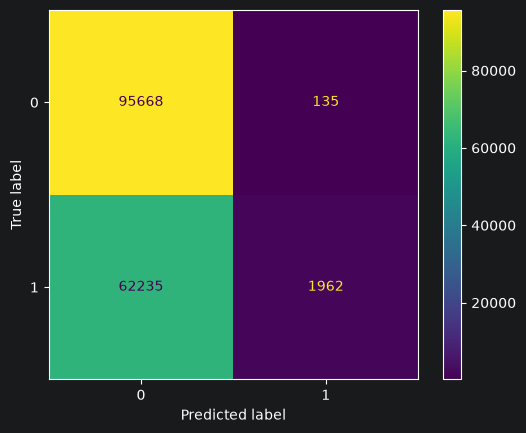

In [11]:
lr_preds = (lr_probs >= best_t_lr).astype(int)
print(classification_report(y, lr_preds))
ConfusionMatrixDisplay.from_predictions(y, lr_preds)
plt.show()

The linear model barely beats the all-zeros benchmark, `$441,990` against `$449,379`, and at its 0.9 threshold recovers only 3% of the positives. The relationship is clearly nonlinear, which means a neural network will surely perform better. Even if the client valued explainability, this problem is so poorly suited to linear regression that we wouldn't recommend a linear model in this case.

## Dense Neural Network

We reuse the Case Study 6 architecture: a 256-128-64 funnel with BCE-with-logits loss and Adam, adding dropout and weight decay as tunable regularizers. Model selection runs on a single stratified 80/20 split for speed; the winning configuration is then retrained with 5-fold CV to produce unbiased predictions for all 160,000 rows.

In [12]:
L.seed_everything(42)
input_size = X.shape[1]

class CostNet(L.LightningModule):
    def __init__(self, lr=1e-3, dropout=0.0, weight_decay=0.0):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.BCEWithLogitsLoss()
        self.layer1 = nn.Linear(input_size, 256)
        self.layer2 = nn.Linear(256, 128)
        self.layer3 = nn.Linear(128, 64)
        self.layer4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        a1 = self.drop(self.relu(self.layer1(x)))
        a2 = self.drop(self.relu(self.layer2(a1)))
        a3 = self.drop(self.relu(self.layer3(a2)))
        return self.layer4(a3)

    def training_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss(self(x), y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        loss = self.loss(self(x), y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr,
                                weight_decay=self.hparams.weight_decay)

### Tuning

Each configuration trains with early stopping on validation loss (patience = 5), then is scored by its cost-minimizing threshold on the validation set. The all-zeros benchmark on the 20% split is printed for reference.

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X.values, y, test_size=0.2, stratify=y, random_state=42)
scaler_nn = StandardScaler()
X_train_s = scaler_nn.fit_transform(X_train).astype(np.float32)
X_val_s = scaler_nn.transform(X_val).astype(np.float32)

train_ds = TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train, dtype=torch.float32).unsqueeze(1))
val_ds = TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val, dtype=torch.float32).unsqueeze(1))
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4096, shuffle=False)
print("all-zeros benchmark on val: $", FN_COST * (y_val == 1).sum())

all-zeros benchmark on val: $ 89873


In [14]:
configs = [(1e-3, 0.0, 0.0), (1e-3, 0.2, 0.0), (1e-3, 0.0, 1e-4),
           (1e-3, 0.2, 1e-4), (1e-4, 0.0, 0.0), (1e-4, 0.2, 1e-4)]
results = []
for lr, dropout, wd in configs:
    L.seed_everything(42)
    model = CostNet(lr=lr, dropout=dropout, weight_decay=wd)
    es = EarlyStopping(patience=5, monitor="val_loss", mode="min")
    ckpt = ModelCheckpoint(save_top_k=1, monitor="val_loss", mode="min", dirpath="checkpoints/")
    trainer = L.Trainer(accelerator="cuda", max_epochs=-1, callbacks=[es, ckpt], logger=False,
                        enable_progress_bar=False, enable_model_summary=False)
    trainer.fit(model, train_loader, val_loader)

    model = CostNet.load_from_checkpoint(ckpt.best_model_path)
    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(torch.tensor(X_val_s).to(model.device))).cpu().numpy().ravel()
    val_costs = [FP_COST * ((val_probs >= t) & (y_val == 0)).sum() + FN_COST * ((val_probs < t) & (y_val == 1)).sum()
                 for t in thresholds]
    results.append((lr, dropout, wd, trainer.current_epoch, thresholds[np.argmin(val_costs)], min(val_costs)))
    print(results[-1])

pd.DataFrame(results, columns=["lr", "dropout", "weight_decay", "epochs", "best_t", "val_cost"])

(0.001, 0.0, 0.0, 12, np.float64(0.89), np.int64(25910))
(0.001, 0.2, 0.0, 41, np.float64(0.91), np.int64(15243))
(0.001, 0.0, 0.0001, 15, np.float64(0.88), np.int64(23115))
(0.001, 0.2, 0.0001, 39, np.float64(0.9), np.int64(14873))
(0.0001, 0.0, 0.0, 49, np.float64(0.87), np.int64(30941))
(0.0001, 0.2, 0.0001, 156, np.float64(0.89), np.int64(14716))


,lr,dropout,weight_decay,epochs,best_t,val_cost
0,0.0010,0.0,0.0000,12,0.89,25910
1,0.0010,0.2,0.0000,41,0.91,15243
2,0.0010,0.0,0.0001,15,0.88,23115
3,0.0010,0.2,0.0001,39,0.90,14873
4,0.0001,0.0,0.0000,49,0.87,30941
5,0.0001,0.2,0.0001,156,0.89,14716


Dropout is critical here, with both dropout configurations landing under `$15,300` against `$23,000` to `$31,000` without and the `$89,873` benchmark. The lr=1e-4 run edges out lr=1e-3 by about 1% at four times the epochs, so we keep lr=1e-3 and push dropout further before committing.

In [15]:
torch.set_float32_matmul_precision("high")
for lr, dropout, wd in [(1e-3, 0.3, 1e-4), (1e-3, 0.4, 1e-4)]:
    L.seed_everything(42)
    model = CostNet(lr=lr, dropout=dropout, weight_decay=wd)
    es = EarlyStopping(patience=5, monitor="val_loss", mode="min")
    ckpt = ModelCheckpoint(save_top_k=1, monitor="val_loss", mode="min", dirpath="checkpoints/")
    trainer = L.Trainer(accelerator="cuda", max_epochs=-1, callbacks=[es, ckpt], logger=False,
                        enable_progress_bar=False, enable_model_summary=False)
    trainer.fit(model, train_loader, val_loader)

    model = CostNet.load_from_checkpoint(ckpt.best_model_path)
    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(torch.tensor(X_val_s).to(model.device))).cpu().numpy().ravel()
    val_costs = [FP_COST * ((val_probs >= t) & (y_val == 0)).sum() + FN_COST * ((val_probs < t) & (y_val == 1)).sum()
                 for t in thresholds]
    results.append((lr, dropout, wd, trainer.current_epoch, thresholds[np.argmin(val_costs)], min(val_costs)))
    print(results[-1])

pd.DataFrame(results, columns=["lr", "dropout", "weight_decay", "epochs", "best_t", "val_cost"])

(0.001, 0.3, 0.0001, 44, np.float64(0.88), np.int64(13923))
(0.001, 0.4, 0.0001, 47, np.float64(0.86), np.int64(14008))


,lr,dropout,weight_decay,epochs,best_t,val_cost
0,0.0010,0.0,0.0000,12,0.89,25910
1,0.0010,0.2,0.0000,41,0.91,15243
2,0.0010,0.0,0.0001,15,0.88,23115
3,0.0010,0.2,0.0001,39,0.90,14873
4,0.0001,0.0,0.0000,49,0.87,30941
5,0.0001,0.2,0.0001,156,0.89,14716
6,0.0010,0.3,0.0001,44,0.88,13923
7,0.0010,0.4,0.0001,47,0.86,14008


Dropout 0.3 wins at `$13,923` on the validation split, so it becomes the final configuration.

### Final Model: 5-Fold Out-of-Fold Predictions

The lowest-cost configuration retrains from scratch five times, once per fold, with 10% of each training fold held aside for early stopping and the scaler fit only on training data. Every row's probability comes from a model that never saw it, which satisfies the unbiased-prediction requirement over all 160,000 samples.

In [16]:
best = results[np.argmin([r[5] for r in results])]
best_lr, best_dropout, best_wd = best[0], best[1], best[2]
print("final config:", best)

oof_probs = np.zeros(len(y))
for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    fit_idx, es_idx = train_test_split(tr_idx, test_size=0.1, stratify=y[tr_idx], random_state=42)
    fold_scaler = StandardScaler().fit(X.values[fit_idx])
    X_fit = fold_scaler.transform(X.values[fit_idx]).astype(np.float32)
    X_es = fold_scaler.transform(X.values[es_idx]).astype(np.float32)
    X_te = fold_scaler.transform(X.values[te_idx]).astype(np.float32)
    fit_loader = DataLoader(TensorDataset(torch.tensor(X_fit), torch.tensor(y[fit_idx], dtype=torch.float32).unsqueeze(1)),
                            batch_size=512, shuffle=True)
    es_loader = DataLoader(TensorDataset(torch.tensor(X_es), torch.tensor(y[es_idx], dtype=torch.float32).unsqueeze(1)),
                           batch_size=4096, shuffle=False)

    L.seed_everything(42)
    model = CostNet(lr=best_lr, dropout=best_dropout, weight_decay=best_wd)
    es = EarlyStopping(patience=5, monitor="val_loss", mode="min")
    ckpt = ModelCheckpoint(save_top_k=1, monitor="val_loss", mode="min", dirpath="checkpoints/")
    trainer = L.Trainer(accelerator="cuda", max_epochs=-1, callbacks=[es, ckpt], logger=False,
                        enable_progress_bar=False, enable_model_summary=False)
    trainer.fit(model, fit_loader, es_loader)

    model = CostNet.load_from_checkpoint(ckpt.best_model_path)
    model.eval()
    with torch.no_grad():
        oof_probs[te_idx] = torch.sigmoid(model(torch.tensor(X_te).to(model.device))).cpu().numpy().ravel()
    print("fold", fold, "stopped at epoch", trainer.current_epoch)

final config: (0.001, 0.3, 0.0001, 44, np.float64(0.88), np.int64(13923))
fold 0 stopped at epoch 42
fold 1 stopped at epoch 50
fold 2 stopped at epoch 51
fold 3 stopped at epoch 40
fold 4 stopped at epoch 48


We sweep the threshold on the out-of-fold probabilities as before. This is the final number that our client is interested in: the total dollar cost over all 160,000 rows, predicted without bias.

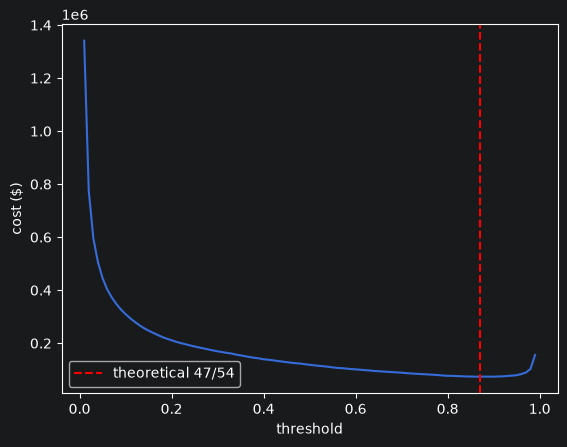

best threshold: 0.87 cost: $ 73539


In [17]:
nn_costs = [FP_COST * ((oof_probs >= t) & (y == 0)).sum() + FN_COST * ((oof_probs < t) & (y == 1)).sum()
            for t in thresholds]
best_t_nn = thresholds[np.argmin(nn_costs)]

plt.plot(thresholds, nn_costs)
plt.axvline(47 / 54, color="red", linestyle="--", label="theoretical 47/54")
plt.xlabel("threshold")
plt.ylabel("cost ($)")
plt.legend()
plt.show()
print("best threshold:", best_t_nn, "cost: $", min(nn_costs))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     95803
           1       0.99      0.92      0.95     64197

    accuracy                           0.96    160000
   macro avg       0.97      0.96      0.96    160000
weighted avg       0.96      0.96      0.96    160000



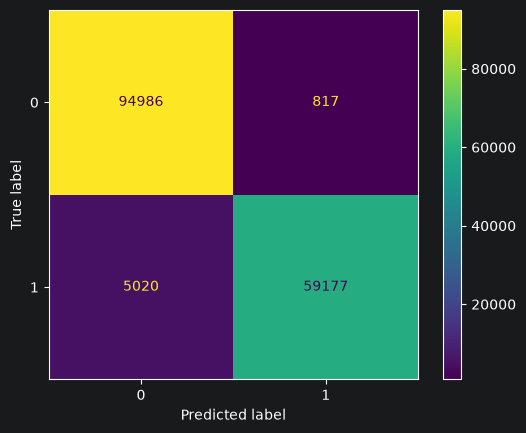

final cost: $ 73539
all-zeros:   $ 449379
logistic:    $ 441990


In [18]:
nn_preds = (oof_probs >= best_t_nn).astype(int)
print(classification_report(y, nn_preds))
ConfusionMatrixDisplay.from_predictions(y, nn_preds)
plt.show()
print("final cost: $", min(nn_costs))
print("all-zeros:   $", FN_COST * (y == 1).sum())
print("logistic:    $", min(lr_costs))

The cost-minimizing threshold lands exactly on the theoretical 47/54, and the high threshold gives us 99% precision on the '$47' class by conceding some recall (since false positives cost less).

## Conclusion

The client asked us to minimize dollar losses on 160,000 unbiased predictions, with false positives costing `$47` and false negatives `$7`. A logistic regression baseline could only trim the all-zeros benchmark from `$449,379` to `$441,990`, while a 256-128-64 dense network with dropout 0.3, weight decay 1e-4, and BCE-with-logits loss cut the out-of-fold cost to `$73,539`. The two elements that mattered were regularization, where dropout roughly halved validation cost, and the decision threshold, where sweeping on out-of-fold probabilities recovered the theoretical optimum of 47/54, predicting the more expensive class only at 87% confidence. Every reported number is out of fold, so no model was ever scored on data it trained on.